# Домашная работа №1

Датасет был взять c kaggle: https://www.kaggle.com/datasets/zabihullah18/students-social-network-profile-clustering


Датасет содержит информацию о профилях старшеклассников в социальных сетях со следующими характеристиками:

#### Демографические данные
- **gradyear** - Год выпуска из школы
- **gender** - Пол ученика (мужской/женский)
- **age** - Возраст на момент опроса

#### Социальная активность
- **NumberOffriends** - Количество друзей/контактов в соцсети

#### Спортивные интересы
- **basketball** - Упоминания баскетбола
- **football** - Упоминания американского футбола
- **soccer** - Упоминания футбола (соккера)
- **softball** - Упоминания софтбола
- **volleyball** - Упоминания волейбола
- **swimming** - Упоминания плавания
- **cheerleading** - Упоминания чирлидинга
- **baseball** - Упоминания бейсбола
- **tennis** - Упоминания тенниса
- **sports** - Общие упоминания спорта

#### Музыкальные предпочтения
- **rock** - Упоминания рок-музыки
- **band** - Упоминания музыкальных групп
- **marching** - Упоминания марширования
- **music** - Упоминания музыки
- **dance** - Упоминания танцев

#### Религиозные темы
- **god** - Упоминания Бога
- **church** - Упоминания церкви
- **jesus** - Упоминания Иисуса
- **bible** - Упоминания Библии

#### Темы связанные шопингом
- **dress** - Упоминания одежды (платьев)
- **clothes** - Упоминания одежды
- **hollister** - Упоминания бренда Hollister
- **abercrombie** - Упоминания бренда Abercrombie
- **mall** - Упоминания торговых центров
- **shopping** - Упоминания шопинга

#### Отношения
- **sex** - Упоминания секса
- **sexy** - Упоминания "сексуальный"
- **hot** - Упоминания "горячий"
- **kissed** - Упоминания поцелуев

#### Внешний вид
- **cute** - Упоминания "милый"
- **hair** - Упоминания причёски
- **blonde** - Упоминания блондинов/блондинок
- **dress** - Упоминания одежды (платьев)
- **clothes** - Упоминания одежды

#### Девиантные темы
- **die** - Упоминания смерти (глагол)
- **death** - Упоминания смерти
- **drunk** - Упоминания алкогольного опьянения
- **drugs** - Упоминания наркотиков

> Примечание: Все показатели измеряются частотой упоминаний в профиле ученика. Бренды (Hollister, Abercrombie) указаны как есть в оригинальном датасете.

### Постановка задачи
Выявить группы учащихся (кластеры) с атипичными поведенческими паттернами в социальных сетях, которые могут свидетельствовать о маргинальном положении в школьном коллективе ("изгои").

### Набор признаков для кластерного анализа
**Спорт**, **Музыка**, **Религия**, **Мода**, **Внешний вид**, **Девиантные темы** - они будут вычисляться как сумма показателей полей слов из этой категории.

Такие признаки выбраны, потому что они отражают ключевые аспекты подростковой социализации: популярные виды активности (спорт, музыка), социально значимые темы (мода, религия, внешний вид) и маркеры неблагополучия (девиантные темы), что в совокупности позволяет выявить отклонения от типичных поведенческих паттернов. 

In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("03_Clustering_Marketing.csv")

data.head()

,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2007,NaN,NaN,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2007,F,17.41,49,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,2007,F,17.511,41,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,1
3,2006,F,NaN,36,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2008,F,16.657,1,0,0,0,0,0,1,...,0,0,0,3,0,0,0,0,0,0


In [3]:
print("Пропущенные значения:\n", data.isnull().sum())

Пропущенные значения:
 gradyear              0
gender             1337
age                2496
NumberOffriends       0
basketball            0
football              0
soccer                0
softball              0
volleyball            0
swimming              0
cheerleading          0
baseball              0
tennis                0
sports                0
cute                  0
sex                   0
sexy                  0
hot                   0
kissed                0
dance                 0
band                  0
marching              0
music                 0
rock                  0
god                   0
church                0
jesus                 0
bible                 0
hair                  0
dress                 0
blonde                0
mall                  0
shopping              0
clothes               0
hollister             0
abercrombie           0
die                   0
death                 0
drunk                 0
drugs                 0
dtype: int64


### Построение матрицы «объект-признак»

In [4]:
df_new = pd.DataFrame()
# Группы столбцов
sports_cols = ['basketball', 'football', 'soccer', 'softball', 'volleyball', 'swimming', 'cheerleading', 'baseball', 'tennis', 'sports']
appearance_cols = ['cute', 'blonde', 'dress', 'clothes', 'hair']
relationships_cols = ['sex', 'sexy', 'hot', 'kissed']
music_cols = ['dance', 'band', 'marching', 'music', 'rock']
religion_cols = ['god', 'church', 'jesus', 'bible']
fashion_cols = ['dress', 'mall', 'shopping', 'clothes', 'hollister', 'abercrombie']
dark_cols = ['die', 'death', 'drunk', 'drugs']

# Суммируем значения по темам
df_new['sports_sum'] = data[sports_cols].sum(axis=1)
df_new['appearance_sum'] = data[appearance_cols].sum(axis=1)
df_new['relationships_sum'] = data[relationships_cols].sum(axis=1)
df_new['music_sum'] = data[music_cols].sum(axis=1)
df_new['religion_sum'] = data[religion_cols].sum(axis=1)
df_new['fashion_sum'] = data[fashion_cols].sum(axis=1)
df_new['dark_sum'] = data[dark_cols].sum(axis=1)
df_new['NumberOffriends'] = data['NumberOffriends']



df_new = df_new.dropna()
print("Матрица «объект-признак»")
df_new

Матрица «объект-признак»


,sports_sum,appearance_sum,relationships_sum,music_sum,religion_sum,fashion_sum,dark_sum,NumberOffriends
0,0,0,0,0,0,0,0,0
1,2,0,0,0,1,0,1,49
2,1,4,3,3,1,1,2,41
3,0,0,0,0,0,0,0,36
4,4,14,2,1,2,3,0,1
...,...,...,...,...,...,...,...,...
14995,0,3,0,1,1,2,1,21
14996,1,0,0,1,2,0,1,50
14997,1,1,0,0,0,0,0,32
14998,0,0,0,1,0,0,0,20


### Нормирование признаков

Для начала посмотри, какие распределения имеют значения признаков.

C:\Users\user\AppData\Local\Temp\ipykernel_15416\383618653.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_new, palette='hsv', alpha=0.5)
C:\Users\user\AppData\Local\Temp\ipykernel_15416\383618653.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_new, palette='hsv', alpha=0.5)
C:\Users\user\AppData\Local\Temp\ipykernel_15416\383618653.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_new, palette='hsv', alpha=0.5)
C:\Users\user\AppData\Local\Temp\ipykernel_15416\383618653.py:8: Futur

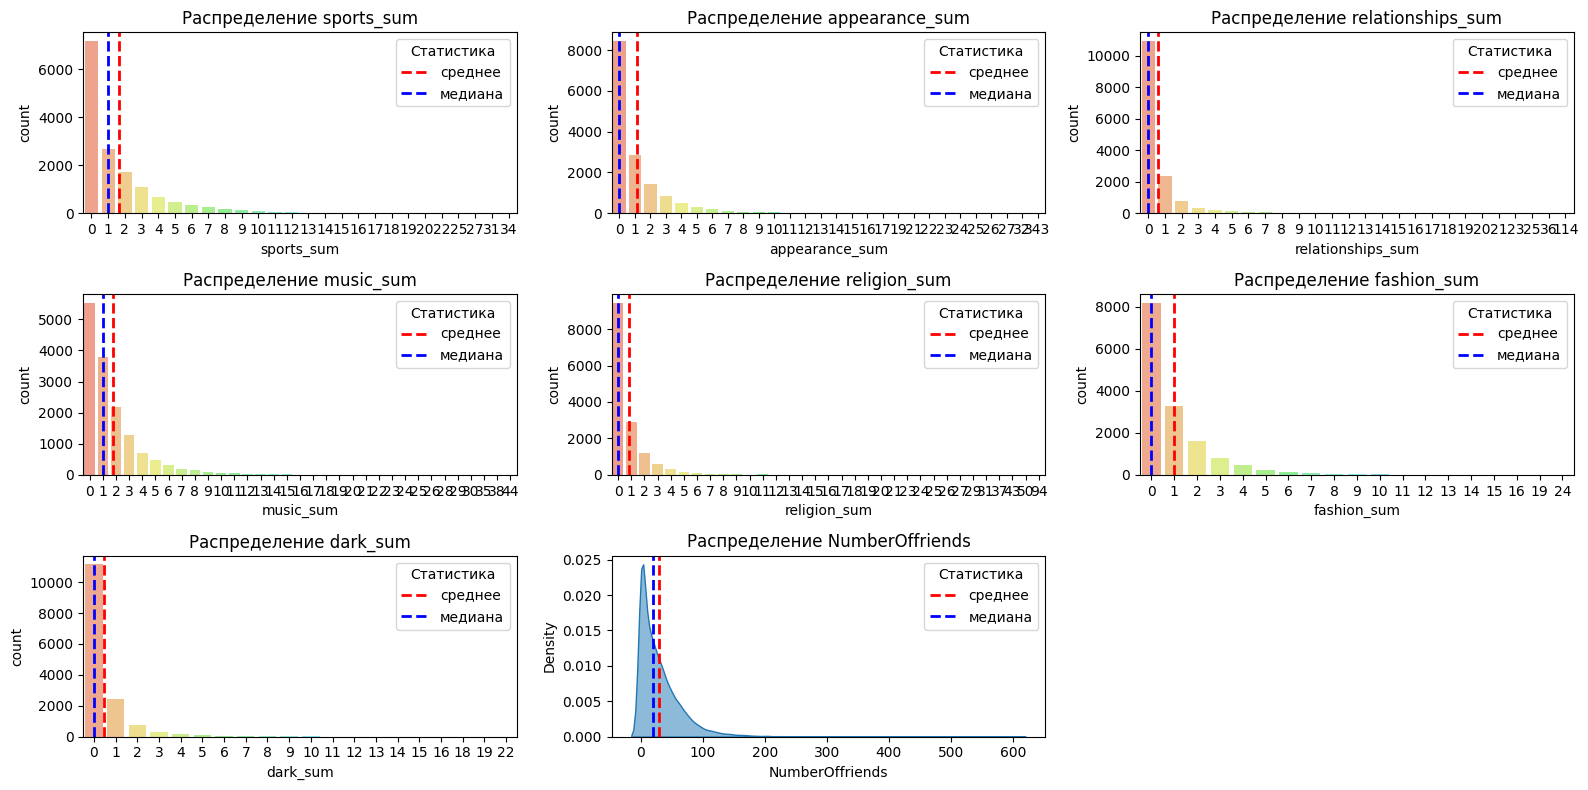

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8))
for i, col in enumerate(df_new.columns):
    plt.subplot(3, 3, i+1)
    if df_new[col].nunique() < 100:
        sns.countplot(x=col, data=df_new, palette='hsv', alpha=0.5)
    else:
        sns.kdeplot(df_new[col], fill=True, alpha=0.5)
    plt.title(f'Распределение {col}')
    
    plt.axvline(df_new[col].mean(), color='red', linestyle='dashed', linewidth=2, label='среднее')
    plt.axvline(df_new[col].median(), color='blue', linestyle='dashed', linewidth=2, label='медиана')
    plt.legend(loc='upper right', title='Статистика')
plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_15416\1297841583.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_norm, palette='hsv', alpha=0.5)
C:\Users\user\AppData\Local\Temp\ipykernel_15416\1297841583.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_norm, palette='hsv', alpha=0.5)
C:\Users\user\AppData\Local\Temp\ipykernel_15416\1297841583.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_norm, palette='hsv', alpha=0.5)
C:\Users\user\AppData\Local\Temp\ipykernel_15416\1297841583.py:9

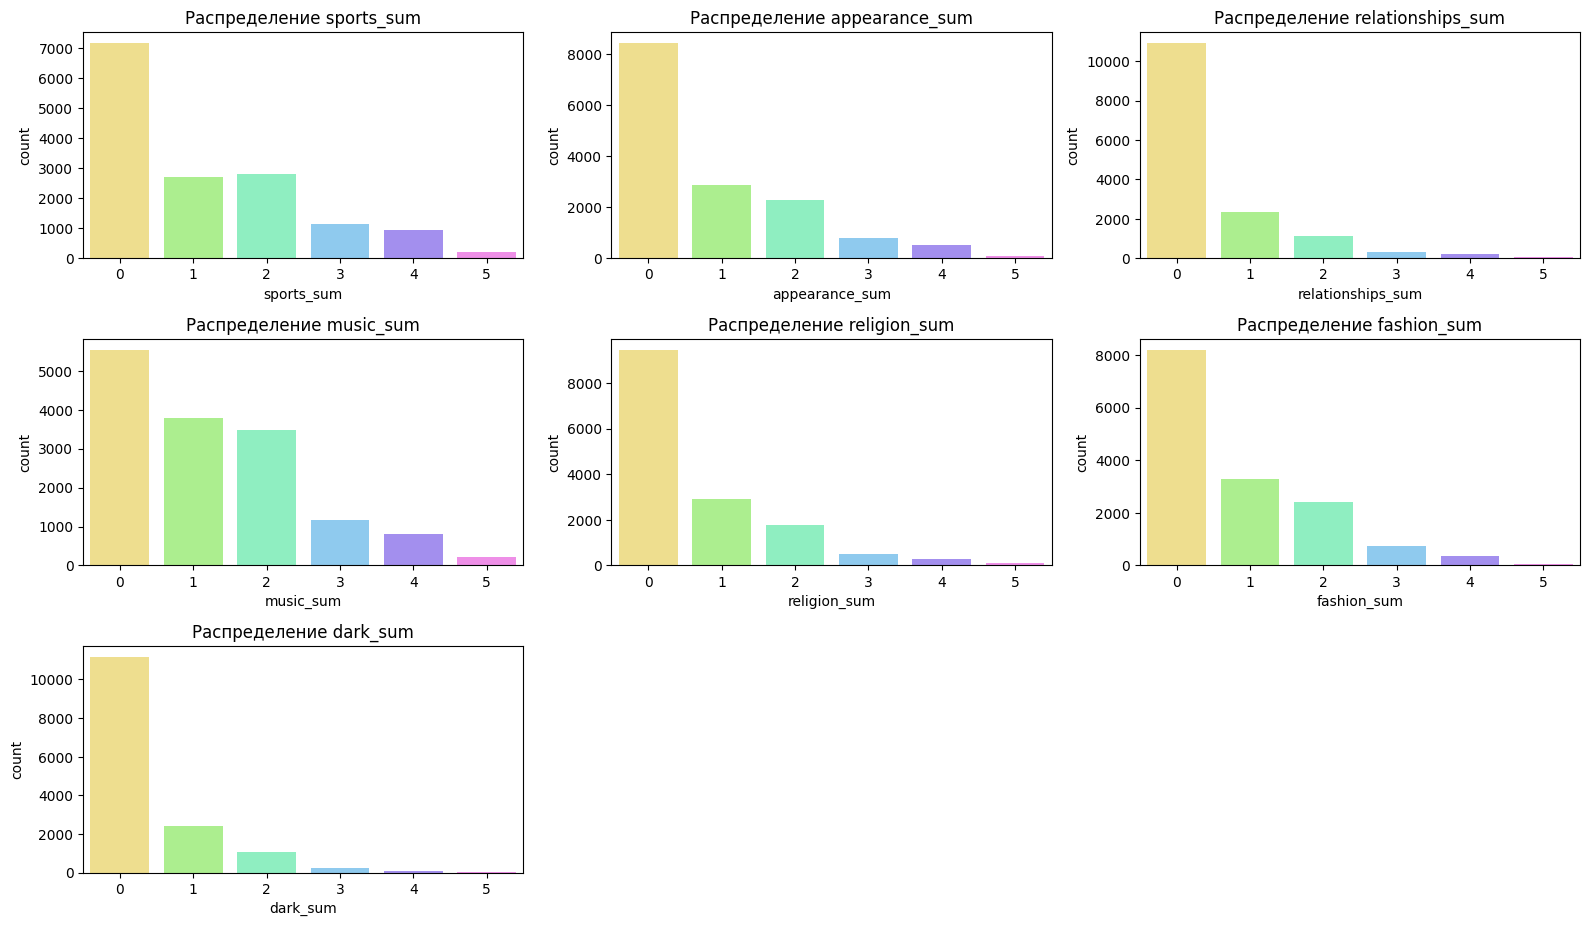

In [6]:
# Бининг
bins = [-1, 0, 1, 3, 5, 10, np.inf]
labels = [0, 1, 2, 3, 4, 5]
df_norm = pd.DataFrame()
plt.figure(figsize=(16, 12))
for i, col in enumerate(df_new.columns.drop('NumberOffriends')):
    plt.subplot(4, 3, i+1)
    df_norm[col] = pd.cut(df_new[col], bins=bins, labels=labels).astype(int)
    sns.countplot(x=col, data=df_norm, palette='hsv', alpha=0.5)
    plt.title(f'Распределение {col}')
plt.tight_layout()
plt.show()

In [7]:
from sklearn.preprocessing import MinMaxScaler
# Определяем порог для обрезания (например, 95-й процентиль)
threshold = df_new['NumberOffriends'].quantile(0.95)

df_clip = pd.DataFrame()
# Обрезаем значения выше порога
df_clip['NumberOffriends'] = df_new['NumberOffriends'].clip(upper=threshold)

# Создаем экземпляр MinMaxScaler с диапазоном от 0 до 5
scaler = MinMaxScaler(feature_range=(0, 5))

# Применяем нормализацию к столбцу 'NumberOffriends'
df_norm['NumberOffriends'] = scaler.fit_transform(df_clip[['NumberOffriends']])

In [8]:
df_norm.head(15)

,sports_sum,appearance_sum,relationships_sum,music_sum,religion_sum,fashion_sum,dark_sum,NumberOffriends
0,0,0,0,0,0,0,0,0.000000
1,2,0,0,0,1,0,1,2.578947
2,1,3,2,2,1,1,2,2.157895
3,0,0,0,0,0,0,0,1.894737
4,3,5,2,1,2,2,0,0.052632
5,3,0,0,2,0,0,0,1.684211
6,0,1,1,0,1,1,0,0.947368
7,0,0,0,0,0,0,0,0.000000
8,1,1,1,3,3,0,0,0.000000
9,1,1,0,0,0,2,0,1.105263


### Матрица «объект-объект» 

In [9]:
from sklearn.metrics import pairwise_distances

df_norm = df_norm.reset_index(drop=True)
# Считаем расстояния между объектами (строками)
distance_matrix = pairwise_distances(df_norm)

# Оформляем результат в DataFrame
df_distance = pd.DataFrame(distance_matrix, index=df_norm.index, columns=df_norm.index)

print(df_distance.head())

      0             1         2         3         4         5         6      \
0  0.000000  3.556820e+00  5.353178  1.894737  6.855857  3.979518  2.213031   
1  3.556820  5.960464e-08  4.491913  2.543255  6.586522  2.792947  3.265279   
2  5.353178  4.491913e+00  0.000000  4.906042  4.408189  4.819168  3.932604   
3  1.894737  2.543255e+00  4.906042  0.000000  7.098827  3.611692  2.213031   
4  6.855857  6.586522e+00  4.408189  7.098827  0.000000  6.376680  5.458988   

      7         8         9      ...     14990     14991     14992     14993  \
0  0.000000  4.582576  2.687305  ...  4.358899  4.269002  1.021920  1.414214   
1  3.556820  4.863226  3.189317  ...  4.526928  4.942887  3.550974  3.827658   
2  5.353178  4.433566  4.371274  ...  4.831223  3.291894  5.176122  4.759885   
3  1.894737  4.958833  2.573571  ...  4.335961  4.474303  1.958715  2.364324   
4  6.855857  5.477478  5.487079  ...  6.920802  4.814279  6.635129  5.916314   

      14994     14995     14996     14997   

In [10]:
mask_zero = (df_norm.sum(axis=1) == 0)
cluster_zero = df_norm[mask_zero].index
print(len(cluster_zero))
print(cluster_zero)
df_norm = df_norm[~mask_zero]
df_norm.head(15)

457
Index([    0,     7,    11,   146,   222,   226,   272,   419,   496,   532,
       ...
       14682, 14692, 14773, 14812, 14867, 14881, 14901, 14938, 14955, 14986],
      dtype='int64', length=457)


,sports_sum,appearance_sum,relationships_sum,music_sum,religion_sum,fashion_sum,dark_sum,NumberOffriends
1,2,0,0,0,1,0,1,2.578947
2,1,3,2,2,1,1,2,2.157895
3,0,0,0,0,0,0,0,1.894737
4,3,5,2,1,2,2,0,0.052632
5,3,0,0,2,0,0,0,1.684211
6,0,1,1,0,1,1,0,0.947368
8,1,1,1,3,3,0,0,0.000000
9,1,1,0,0,0,2,0,1.105263
10,0,1,1,1,2,0,0,0.000000
12,0,1,0,1,0,0,0,1.526316


In [ ]:
df_norm = df_norm.reset_index(drop=True)
df_norm['NumberOffriends'] = df_norm['NumberOffriends'].round(1)
# Считаем расстояния между объектами (строками)
distance_matrix = pairwise_distances(df_norm)

# Оформляем результат в DataFrame
df_distance = pd.DataFrame(distance_matrix, index=df_norm.index, columns=df_norm.index)

print(df_distance.head(10))

          0         1         2         3         4             5      \
0  5.960464e-08  4.489989  2.547548  6.576473  2.794638  3.300000e+00   
1  4.489989e+00  0.000000  4.908156  4.405678  4.821825  3.961060e+00   
2  2.547548e+00  4.908156  0.000000  7.088018  3.611094  2.236068e+00   
3  6.576473e+00  4.405678  7.088018  0.000000  6.368673  5.444263e+00   
4  2.794638e+00  4.821825  3.611094  6.368673  0.000000  4.200000e+00   
5  3.300000e+00  3.961060  2.236068  5.444263  4.200000  4.214685e-08   
6  4.874423e+00  4.454211  4.960847  5.478138  4.346263  3.976179e+00   
7  3.201562e+00  4.382921  2.576820  5.477226  3.655133  2.009975e+00   
8  3.969887e+00  4.223742  3.257299  5.478138  4.346263  1.951922e+00   
9  3.034798e+00  4.060788  1.469694  6.241795  3.322650  2.088061e+00   

      6         7         8         9      ...     14533     14534     14535  \
0  4.874423  3.201562  3.969887  3.034798  ...  4.534314  4.940648  3.572114   
1  4.454211  4.382921  4.223742  4.0

In [46]:
np.fill_diagonal(distance_matrix, 0)
df_distance = pd.DataFrame(distance_matrix, index=df_norm.index, columns=df_norm.index)

print(df_distance.head())

      0         1         2         3         4         5         6      \
0  0.000000  4.489989  2.547548  6.576473  2.794638  3.300000  4.874423   
1  4.489989  0.000000  4.908156  4.405678  4.821825  3.961060  4.454211   
2  2.547548  4.908156  0.000000  7.088018  3.611094  2.236068  4.960847   
3  6.576473  4.405678  7.088018  0.000000  6.368673  5.444263  5.478138   
4  2.794638  4.821825  3.611094  6.368673  0.000000  4.200000  4.346263   

      7         8         9      ...     14533     14534     14535     14536  \
0  3.201562  3.969887  3.034798  ...  4.534314  4.940648  3.572114  3.841875   
1  4.382921  4.223742  4.060788  ...  4.841487  3.300000  5.196152  4.779121   
2  2.576820  3.257299  1.469694  ...  4.337050  4.467662  1.972308  2.368544   
3  5.477226  5.478138  6.241795  ...  6.914478  4.812484  6.634003  5.916925   
4  3.655133  4.346263  3.322650  ...  3.080584  5.695612  4.031129  4.229657   

      14537     14538     14539     14540     14541     14542  
0  2

### Алгоритм кластеризации

In [47]:
import numpy as np
import heapq
from tqdm import tqdm


# df_distance — DataFrame, индексы от 0 до n-1
n = len(df_distance)
dist_matrix = df_distance.values  # numpy array для быстрого доступа

visited = np.zeros(n, dtype=bool) # массив пометок в дереве вершина или нет
min_edge = [np.inf] * n  # минимальное расстояние до остовного дерева
from_node = [-1] * n     # откуда пришли

# Начинаем с вершины 0 (которая соответствует индексу 0 в df)
min_edge[0] = 0

# это структура данных по названием куча, где будут хранятся ребра и из которой за O(1) можно достать минимальное ребро по весу 
heap = [(0, 0)]  # (вес, вершина)

# Тут будем записывать ребра, которые будут принадлежать минимальному покрывающему дереву(МПД)
mst_edges = []

with tqdm(total=n - 1, desc='Быстрый Прим') as pbar:
    while heap and len(mst_edges) < n - 1: # Остановка алгоритма: если новых ребер больше нет или мы присоединили все вершины к дереву
        weight, u = heapq.heappop(heap) # Получаем ребро до ближайщей вершины от нашего дерева
        if visited[u]: # если вершина уже в дереве, то проскаем это ребро
            continue
        visited[u] = True # помечаем, что вершина в дереве

        # Если это не начальная вершина — добавим ребро в дерево
        if from_node[u] != -1:
            mst_edges.append((from_node[u], u, weight)) 
            pbar.update(1)

        # Добавим новые ребра, которые инцидентны новой вершине, в кучу.
        for v in range(n):
            # условие, чтобы не добавлять ребра с вершинами, которые уже в дереве
            # и ребра, которые не уменьшать расстояние до новых вершин.
            if not visited[v] and dist_matrix[u, v] < min_edge[v]: 
                # обновляем информацию и добавляем в кучу
                min_edge[v] = dist_matrix[u, v]
                from_node[v] = u
                heapq.heappush(heap, (min_edge[v], v))

Быстрый Прим: 100%|██████████| 14542/14542 [00:22<00:00, 647.02it/s] 


In [13]:
from collections import defaultdict, deque

def split_mst_by_jump(mst_edges, n_nodes):
    """
    mst_edges: список кортежей (u, v, weight) — рёбра MST
    n_nodes: количество вершин в графе
    """
    # 1. Упорядочим рёбра по убыванию длины
    sorted_edges = sorted(mst_edges, key=lambda x: x[2], reverse=True)
    weights = [edge[2] for edge in sorted_edges]

    # 2. Вычисляем g_i = d_{i-1} / d_i
    g = [weights[i - 1] / weights[i] for i in range(1, len(weights))]

    # 3. Ищем минимальное k такое, что g_k < g_{k+1}
    k = None
    for i in range(1, len(g) - 1):
        if g[i] > g[i + 1]:  # по тексту: g_k < g_{k+1}, но тут обратный порядок
            k = i + 1  # +1 потому что g начинается с индекса 1
            break

    # Если не нашли — значит, не будем резать дерево
    if k is None:
        return [sorted_edges], 1

    # 4. Удалим (k - 1) самых длинных рёбер → получим k компонент
    remaining_edges = sorted_edges[k - 1:]

    # 5. Строим таблицу смежности графа
    graph = defaultdict(list)
    for u, v, _ in remaining_edges:
        graph[u].append(v)
        graph[v].append(u)

    # 6. BFS для поиска компонент связности
    visited = set() # множество вершин, определеных в кластеры
    clusters = [] # массив кластеров, где каждый кластер - это массив номеров вершин принадлежащих кластеру.

    # Проходим по всем вершинам
    for node in range(0, n_nodes):
        if node not in visited: # если вершина еще не в кластере, то собираем новый кластер с началом в этой вершине 
            # Дальше идет стандарный обход графа BFS, где вершины добавляются в новый кластер
            cluster = [node] # список вершин в новом кластере
            queue = deque([node]) # Это дек, но будет использоваться как очередь для алгоритма BFS
            visited.add(node)

            while queue:
                curr = queue.popleft()
                for neighbor in graph[curr]: # Проходим по всем соседям новый вершины, и не добавленных в кластер, добавляем в кластер и в очередь
                    if neighbor not in visited:
                        cluster.append(neighbor)
                        visited.add(neighbor)
                        queue.append(neighbor)
            
            clusters.append(cluster)

    return k, clusters
    

In [14]:
def split_mst_by_local_ratio_bfs(mst_edges, n_nodes):
    """
    Делит MST по эвристике локального отношения веса к соседним.
    """
    # 1. Построим граф смежности и сохраним веса
    graph = defaultdict(list)
    edge_weights = {}
    
    for u, v, w in mst_edges:
        graph[u].append((v, w))
        graph[v].append((u, w))
        edge_weights[frozenset((u, v))] = w

    # 2. Найдём локальные пики по отношению
    cut_edges = set()
    
    for u, v, w in mst_edges:
        # Найдём соседние рёбра, исключая (u, v)
        neighbors = []
        for node, other in [(u, v), (v, u)]:
            for nb, w_nb in graph[node]:
                if nb != other:
                    neighbors.append(w_nb)
        
        if neighbors:
            max_neighbor_weight = max(neighbors)
            ratio = w / max_neighbor_weight

            # Теперь найдём "соседние отношения" и проверим, меньше ли они 1
            neighbor_ratios = [w_nb / w if w != 0 else 0 for w_nb in neighbors]
            if ratio > 1 and all(r < 1 for r in neighbor_ratios):
                cut_edges.add(frozenset((u, v)))

    # 3. Удалим найденные рёбра из графа
    cut_graph = defaultdict(list)
    for u, v, w in mst_edges:
        if frozenset((u, v)) not in cut_edges:
            cut_graph[u].append(v)
            cut_graph[v].append(u)

    # 4. BFS по компонентам
    visited = set()
    clusters = []

    for node in range(0, n_nodes):
        if node not in visited:
            cluster = []
            queue = deque([node])
            visited.add(node)

            while queue:
                curr = queue.popleft()
                cluster.append(curr)
                for neighbor in cut_graph[curr]:
                    if neighbor not in visited:
                        visited.add(neighbor)
                        queue.append(neighbor)

            clusters.append(cluster)

    return len(clusters), clusters

In [15]:
from collections import defaultdict, deque

def w_total(df , k, clusters):
    """
    df: датасет с данными
    k: количество кластеров
    clusters: cписок кластеров с индексам студентов
    """
    total_w = 0.0

    for cluster in clusters:
        if len(cluster) == 0:
            continue
        cluster_data = df.iloc[cluster].values
        centroid = cluster_data.mean(axis=0)
        
        # Нормируем центроид
        centroid_norm = np.linalg.norm(centroid)
        if centroid_norm == 0:
            continue
        centroid = centroid / centroid_norm

        # Для каждого объекта считаем 1 - косинусную близость к центру
        for x in cluster_data:
            x_norm = np.linalg.norm(x)
            if x_norm == 0:
                continue
            cos_sim = np.dot(x, centroid) / (x_norm * 1.0)  # centroid уже нормирован
            cos_dist = 1 - cos_sim
            total_w += cos_dist

    return total_w


def split_mst_by_k_clusters(mst_edges, n_nodes, k):
    """
    mst_edges: список кортежей (u, v, weight) — рёбра MST
    n_nodes: количество вершин в графе
    k: количество кластеров на которые нужно разделить
    """
    # 1. Упорядочим рёбра по убыванию длины
    sorted_edges = sorted(mst_edges, key=lambda x: x[2], reverse=True)

    # 2. Удалим (k - 1) самых длинных рёбер → получим k компонент
    remaining_edges = sorted_edges[k - 1:]

    # 2. Строим таблицу смежности графа
    graph = defaultdict(list)
    for u, v, _ in remaining_edges:
        graph[u].append(v)
        graph[v].append(u)

    # 3. BFS для поиска компонент связности
    visited = set() # множество вершин, определеных в кластеры
    clusters = [] # массив кластеров, где каждый кластер - это массив номеров вершин принадлежащих кластеру.

    # Проходим по всем вершинам
    for node in range(0, n_nodes):
        if node not in visited: # если вершина еще не в кластере, то собираем новый кластер с началом в этой вершине 
            # Дальше идет стандарный обход графа BFS, где вершины добавляются в новый кластер
            cluster = [node] # список вершин в новом кластере
            queue = deque([node]) # Это дек, но будет использоваться как очередь для алгоритма BFS
            visited.add(node)

            while queue:
                curr = queue.popleft()
                for neighbor in graph[curr]: # Проходим по всем соседям новый вершины, и не добавленных в кластер, добавляем в кластер и в очередь
                    if neighbor not in visited:
                        cluster.append(neighbor)
                        visited.add(neighbor)
                        queue.append(neighbor)
            
            clusters.append(cluster)

    

    return k, clusters

In [16]:
print(mst_edges)
print(n)


[(0, 513, np.float64(0.2631578947368421)), (0, 119, np.float64(0.2631578947368455)), (119, 10035, np.float64(0.2631578947368455)), (10035, 2403, np.float64(0.15789473684211225)), (513, 9456, np.float64(0.7894736842105274)), (9456, 7837, np.float64(1.0)), (7837, 9715, np.float64(0.3684210526315805)), (9715, 6332, np.float64(0.578947368421052)), (6332, 11691, np.float64(0.10526315789474056)), (11691, 13790, np.float64(0.42105263157894746)), (13790, 6131, np.float64(0.0526315789473745)), (6131, 10746, np.float64(0.0)), (6131, 12263, np.float64(0.0)), (7837, 650, np.float64(0.8421052631578939)), (6131, 1240, np.float64(1.0)), (1240, 3478, np.float64(0.0)), (1240, 6425, np.float64(0.0)), (1240, 8008, np.float64(0.0)), (1240, 10453, np.float64(0.0)), (1240, 10498, np.float64(0.0)), (1240, 13472, np.float64(0.0)), (1240, 11936, np.float64(0.21052631578947267)), (11936, 12182, np.float64(0.10526315789474056)), (12182, 12254, np.float64(0.42105263157894535)), (12254, 13797, np.float64(0.1052631

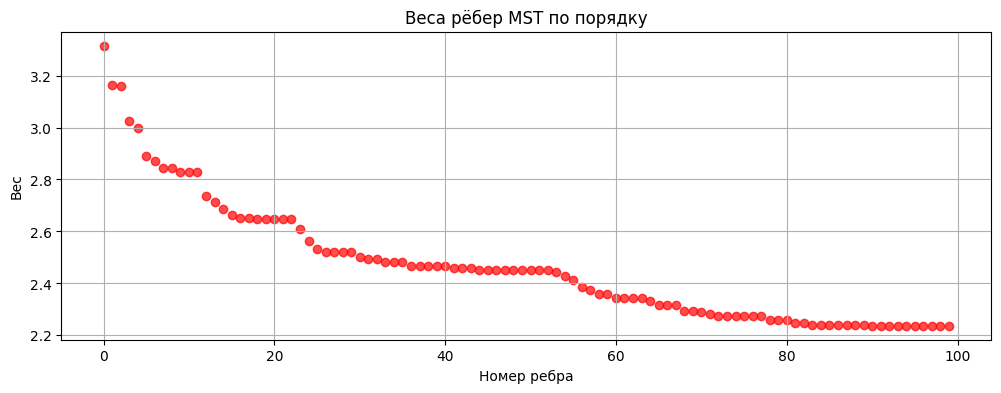

In [61]:
weights = [edge[2] for edge in sorted(mst_edges, key=lambda x: x[2], reverse=True)]
plt.figure(figsize=(12, 4))
plt.scatter(range(100), weights[:100], alpha=0.7, color='red')
plt.title('Веса рёбер MST по порядку')
plt.xlabel('Номер ребра')
plt.ylabel('Вес')
plt.grid(True)
plt.show()

In [49]:
k, clusters = split_mst_by_jump(mst_edges, n)
print(k)
for i in range(k):
    print(f"{i+1} cluster:{clusters[i]}")
    print(len(clusters[i]))

3
1 cluster:[0, 513, 119, 14122, 9456, 10035, 11431, 6843, 5655, 11831, 2403, 4619, 13749, 4938, 11407, 3979, 10713, 529, 9994, 8310, 5627, 3003, 1821, 2791, 8294, 11070, 319, 581, 3490, 150, 1785, 9138, 9913, 10823, 13034, 2038, 810, 12534, 3264, 4750, 5011, 5580, 10262, 4301, 4245, 2478, 4433, 6725, 9536, 7773, 10954, 11888, 780, 4784, 6803, 10267, 10284, 13028, 58, 8358, 10481, 11132, 12888, 13655, 3729, 4768, 10047, 8944, 14008, 6558, 11840, 2059, 4317, 11091, 11196, 12407, 31, 6760, 1119, 10799, 2582, 5181, 6161, 7971, 574, 4552, 7092, 10452, 3995, 5214, 5318, 11444, 7016, 10562, 12506, 14209, 11215, 9288, 295, 4559, 10649, 6774, 10507, 8769, 11569, 9788, 7524, 9598, 13167, 5600, 9909, 7611, 7120, 1616, 4998, 157, 13741, 9780, 2472, 408, 7196, 1645, 2111, 4914, 1556, 229, 12107, 13286, 1451, 4494, 4450, 12641, 4721, 12572, 13315, 5443, 12129, 13968, 1955, 5834, 10392, 3210, 1598, 3281, 6343, 499, 2272, 4, 5743, 2132, 3543, 7629, 1361, 132, 1226, 11171, 11712, 8821, 7069, 3930, 118

C:\Users\user\AppData\Local\Temp\ipykernel_15416\2479415950.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  g = [weights[i - 1] / weights[i] for i in range(1, len(weights))]
C:\Users\user\AppData\Local\Temp\ipykernel_15416\2479415950.py:13: RuntimeWarning: invalid value encountered in scalar divide
  g = [weights[i - 1] / weights[i] for i in range(1, len(weights))]


In [50]:
k, clusters = split_mst_by_local_ratio_bfs(mst_edges, n)
print(k)
for i in range(k):
    print(f"{i+1} cluster:{clusters[i]}")
    print(len(clusters[i]))

2548
1 cluster:[0, 119, 513, 10035, 9456, 2403, 5655, 11831, 11431, 529, 11407, 4938, 10713, 4619, 5627, 8310, 9994, 11070, 8294, 2038, 9138, 9913, 10823, 13034, 1785, 150, 581, 3490, 4768, 8358, 10481, 11132, 12888, 13655, 780, 4784, 6803, 10267, 10284, 13028, 11888, 2478, 4245, 4301, 4750, 5011, 5580, 10262, 10954, 7773, 9536, 4433, 6725, 4559, 4552, 7092, 574, 6161, 7971, 5181, 11091, 11196, 12407, 4317, 2059, 6558, 11840, 31, 1119, 6760, 2582, 10799, 12506, 14209, 10562, 3995, 10452, 11444, 5318, 5214, 12129, 4914, 7611, 9909, 5600, 7524, 9788, 11569, 8769, 13167, 9598, 1616, 4998, 7120, 9780, 13741, 7196, 408, 1556, 13286, 229, 1361, 7629, 3543, 2272, 6343, 3281, 1598, 2132, 4, 1226, 132, 11813, 7069, 4282, 5187, 10567, 14426, 9523, 103, 7245, 2183, 6055, 1015, 4875, 14004, 7271, 2306, 5843, 10718, 3618, 12870, 1072, 4145, 9010, 8198, 10195, 6966, 8698, 2576, 8439, 9537, 1794, 3349, 6533, 2253, 13656, 8860, 8615, 12390, 6371, 3437, 12668, 7254, 8681, 2586, 14466, 3833, 530, 12494,

Считаем W_total: 100%|██████████| 98/98 [00:05<00:00, 16.55it/s]


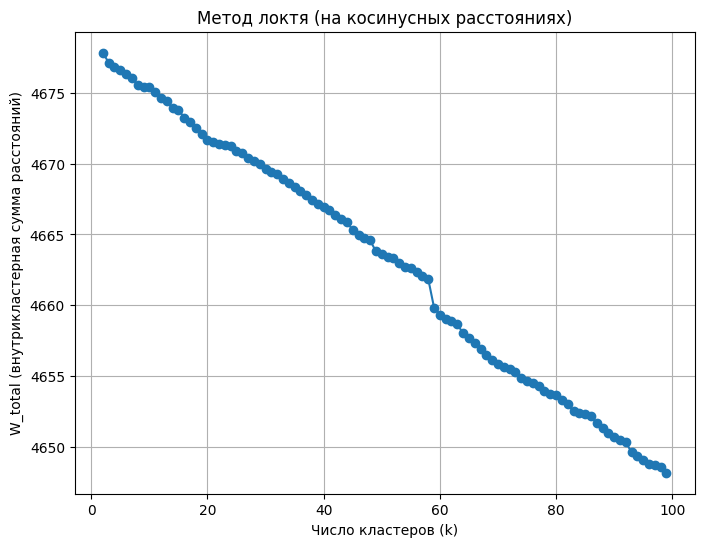

In [51]:
w_scores = []
k_range = range(2, 100)

for k in tqdm(k_range, desc="Считаем W_total"):
    _, clusters = split_mst_by_k_clusters(mst_edges, n, k)
    w = w_total(df_norm, k, clusters)
    w_scores.append(w)

plt.figure(figsize=(8, 6))
plt.plot(list(k_range), w_scores, marker='o')
plt.title("Метод локтя (на косинусных расстояниях)")
plt.xlabel("Число кластеров (k)")
plt.ylabel("W_total (внутрикластерная сумма расстояний)")
plt.grid(True)
plt.show()

Считаем W_total: 100%|██████████| 18/18 [00:00<00:00, 18.02it/s]


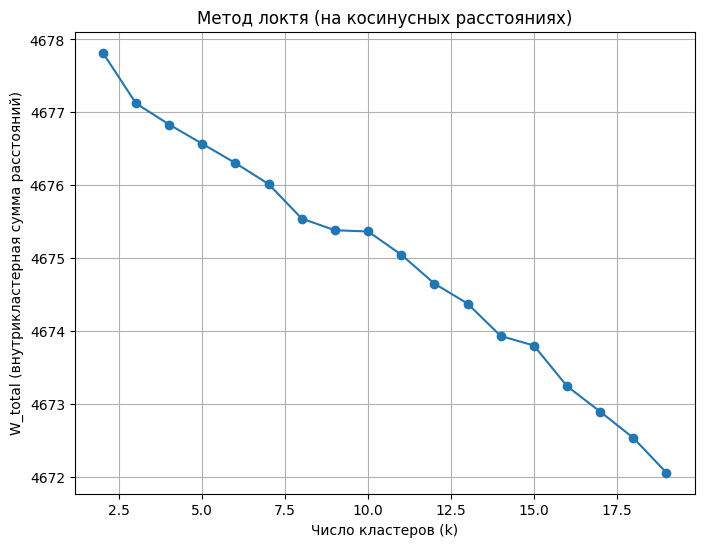

In [52]:
w_scores = []
k_range = range(2, 20)

for k in tqdm(k_range, desc="Считаем W_total"):
    _, clusters = split_mst_by_k_clusters(mst_edges, n, k)
    w = w_total(df_norm, k, clusters)
    w_scores.append(w)

plt.figure(figsize=(8, 6))
plt.plot(list(k_range), w_scores, marker='o')
plt.title("Метод локтя (на косинусных расстояниях)")
plt.xlabel("Число кластеров (k)")
plt.ylabel("W_total (внутрикластерная сумма расстояний)")
plt.grid(True)
plt.show()

In [58]:
k = 6
_, clusters = split_mst_by_k_clusters(mst_edges, n, k)

In [59]:
print(k)
for i in range(k):
    print(f"{i+1} cluster:{clusters[i]}")
    print(len(clusters[i]))


6
1 cluster:[0, 513, 119, 14122, 9456, 10035, 11431, 6843, 5655, 11831, 2403, 4619, 13749, 4938, 11407, 3979, 10713, 529, 9994, 8310, 5627, 3003, 1821, 2791, 8294, 11070, 319, 581, 3490, 150, 1785, 9138, 9913, 10823, 13034, 2038, 810, 12534, 3264, 4750, 5011, 5580, 10262, 4301, 4245, 2478, 4433, 6725, 9536, 7773, 10954, 11888, 780, 4784, 6803, 10267, 10284, 13028, 58, 8358, 10481, 11132, 12888, 13655, 3729, 4768, 10047, 8944, 14008, 6558, 11840, 2059, 4317, 11091, 11196, 12407, 31, 6760, 1119, 10799, 2582, 5181, 6161, 7971, 574, 4552, 7092, 10452, 3995, 5214, 5318, 11444, 7016, 10562, 12506, 14209, 11215, 9288, 295, 4559, 10649, 6774, 10507, 8769, 11569, 9788, 7524, 9598, 13167, 5600, 9909, 7611, 7120, 1616, 4998, 157, 13741, 9780, 2472, 408, 7196, 1645, 2111, 4914, 1556, 229, 12107, 13286, 1451, 4494, 4450, 12641, 4721, 12572, 13315, 5443, 12129, 13968, 1955, 5834, 10392, 3210, 1598, 3281, 6343, 499, 2272, 4, 5743, 2132, 3543, 7629, 1361, 132, 1226, 11171, 11712, 8821, 7069, 3930, 118

In [62]:
dfs = [pd.DataFrame()] * k
for i in range(k):
    dfs[i] = df_norm.loc[clusters[i]]
    print(f"Кластер {i}")
    print(dfs[i].describe())
    print()

Кластер 0
         sports_sum  appearance_sum  relationships_sum     music_sum  \
count  14538.000000    14538.000000       14538.000000  14538.000000   
mean       1.142454        0.847297           0.460517      1.276310   
std        1.329780        1.147719           0.883837      1.251842   
min        0.000000        0.000000           0.000000      0.000000   
25%        0.000000        0.000000           0.000000      0.000000   
50%        1.000000        0.000000           0.000000      1.000000   
75%        2.000000        2.000000           1.000000      2.000000   
max        5.000000        5.000000           5.000000      5.000000   

       religion_sum   fashion_sum      dark_sum  NumberOffriends  \
count  14538.000000  14538.000000  14538.000000     14538.000000   
mean       0.654285      0.817719      0.392970         1.510655   
std        1.014121      1.062501      0.763044         1.469554   
min        0.000000      0.000000      0.000000         0.000000   
2

In [44]:
from sklearn.metrics import silhouette_samples, silhouette_score
import seaborn as sns
def print_siluet(df_norm, distance_matrix, clusters, box_plot = True):
    df_norm['cluster'] = -1

    # Заполняем номера кластеров
    for cluster_num, cluster_indices in enumerate(clusters):
        df_norm.loc[cluster_indices, 'cluster'] = cluster_num

    

    silhouette_vals = silhouette_samples(distance_matrix, df_norm['cluster'], metric='precomputed')

    df_norm['silhouette'] = silhouette_vals

    if box_plot:
        # Визуализация распределения силуэтов по кластерам
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='cluster', y='silhouette', data=df_norm, palette='viridis')
        plt.title('Распределение силуэтных коэффициентов по кластерам')
        plt.xlabel('Номер кластера')
        plt.ylabel('Силуэтный коэффициент')
        plt.grid(True)
        plt.show()

    # Выводим объекты с отрицательным силуэтом (потенциально ошибочно классифицированные)
    problematic_students = df_norm[df_norm['silhouette'] < 0]
    print(f"\nОбъекты с отрицательным силуэтом ({len(problematic_students)} шт.):")
    print(problematic_students[['cluster', 'silhouette']].sort_values('silhouette'))

    # Средний силуэт для всего набора данных
    avg_silhouette = silhouette_score(distance_matrix, df_norm['cluster'], metric='precomputed')
    print(f"\nСредний силуэтный коэффициент: {avg_silhouette:.3f}")

    return df_norm

Считаем индексы силиуэта: 100%|██████████| 98/98 [02:58<00:00,  1.82s/it]


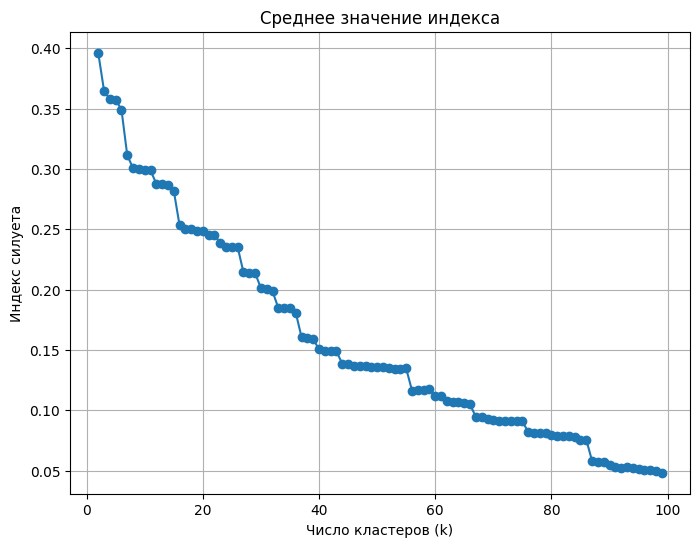

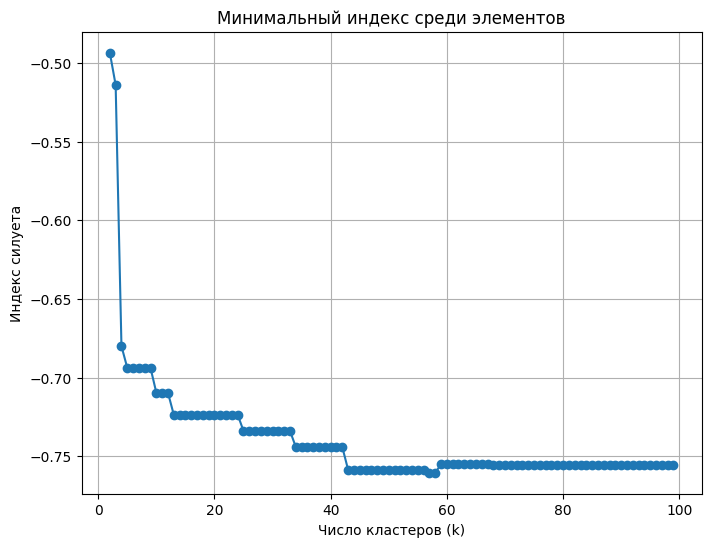

In [57]:
k_range = range(2, 100)
from sklearn.metrics import silhouette_samples, silhouette_score

avg_score = []
min_score = []
for k in tqdm(k_range, desc="Считаем индексы силиуэта"):
    _, clusters = split_mst_by_k_clusters(mst_edges, n, k)
    df_clusters = df_norm.copy()
    df_clusters['cluster'] = -1

    # Заполняем номера кластеров
    for cluster_num, cluster_indices in enumerate(clusters):
        df_clusters.loc[cluster_indices, 'cluster'] = cluster_num
    
    avg_score.append(silhouette_score(distance_matrix, df_clusters['cluster'], metric='precomputed'))

    min_score.append(silhouette_samples(distance_matrix, df_clusters['cluster'], metric='precomputed').min())

plt.figure(figsize=(8, 6))
plt.plot(list(k_range), avg_score, marker='o')
plt.title("Среднее значение индекса")
plt.xlabel("Число кластеров (k)")
plt.ylabel("Индекс силуета")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(list(k_range), min_score, marker='o')
plt.title("Минимальный индекс среди элементов")
plt.xlabel("Число кластеров (k)")
plt.ylabel("Индекс силуета")
plt.grid(True)
plt.show()
    

C:\Users\user\AppData\Local\Temp\ipykernel_15416\883845240.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='silhouette', data=df_norm, palette='viridis')


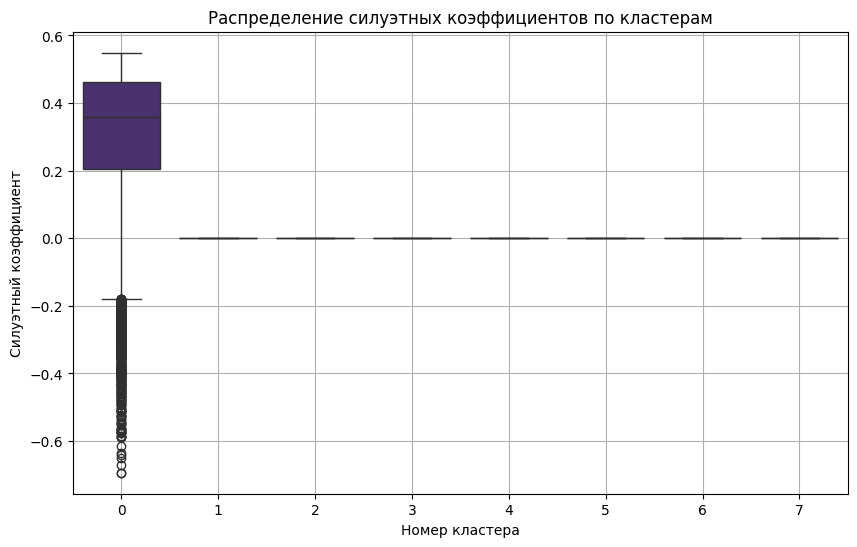


Объекты с отрицательным силуэтом (1416 шт.):
       cluster  silhouette
9299         0   -0.693742
11477        0   -0.693704
11172        0   -0.671271
5863         0   -0.650101
1585         0   -0.641394
...        ...         ...
11483        0   -0.001043
13923        0   -0.000700
12056        0   -0.000413
5971         0   -0.000315
2758         0   -0.000212

[1416 rows x 2 columns]

Средний силуэтный коэффициент: 0.301


In [56]:
df_clusters = print_siluet(df_norm, distance_matrix, clusters)

In [ ]:
bad_cluster = []
for i in range(0, df_clusters['cluster'].max()):
    if df_clusters[df_clusters['cluster'] == i]['silhouette'].mean() < 0:
        bad_cluster.append(i)

len(bad_cluster)

1

In [ ]:
df_clusters

,sports_sum,appearance_sum,music_sum,religion_sum,fashion_sum,dark_sum,cluster,silhouette
0,2,0,0,1,0,1,0,-0.548987
1,1,4,2,1,1,2,0,-0.111025
2,3,5,1,2,2,0,0,0.243740
3,3,0,2,0,0,0,0,0.252656
4,0,1,0,1,1,0,0,-0.217165
...,...,...,...,...,...,...,...,...
13757,0,1,1,1,2,1,0,-0.777798
13758,1,0,1,2,0,1,0,-0.549242
13759,1,1,0,0,0,0,0,0.180483
13760,0,0,1,0,0,0,0,0.126638
